# Post processing ParTI Results

This code allows us to:
1) Visualize the generated polytope
2) Calculate t-ratio 
2) Identify cells proximal to each archetype
3) Analyze the density of cells throughout the ParTI polytope
4) Identify 

In [ ]:
## Load dependencies
import pandas as pd
import numpy as np
import os
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.spatial import distance
import scanpy as sc
import anndata as ad
from matplotlib import cm
from matplotlib.lines import Line2D
import scipy.sparse

## Load in Data & ParTI Results

In [ ]:
## load in the original anndata object data
adata = sc.read_h5ad(r'path/to/adata_balanced_gentamicin_distribution_min_per_bin.h5ad')

In [3]:
# load in matlab ParTI output


# File paths - UPDATE THESE TO YOUR ACTUAL PATHS
# mat_file_path = r"path/to/ParTI_output.mat"
mat_file_path = r"path/to/ParTI_output.mat"

mat_data = sio.loadmat(mat_file_path)
print(mat_data.keys())


gene_names_file_path = r"path/to/ParTI_gene_names.txt"

dict_keys(['__header__', '__version__', '__globals__', 'arc', 'arcOrig', 'errs', 'pc', 'pval'])


In [ ]:
#load in the sample metadata
meta_data = pd.read_csv(r"path/to/ParTI_discrete_attributes.csv", index_col=0)

In [ ]:
## subset adata by meta_data (only keep the data for the samples in our subset)
adata = adata[adata.obs.index.isin(meta_data.index)]

In [6]:
## Data points in the PC space
pc_df = pd.DataFrame(mat_data["pc"], columns=[f"PC{i+1}" for i in range(mat_data["pc"].shape[-1])], index=meta_data.index)
pc_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC4504,PC4505,PC4506,PC4507,PC4508,PC4509,PC4510,PC4511,PC4512,PC4513
orig.ident,,,,,,,,,,,,,,,,,,,,,
SeuratProject,-2.167996,-3.588033,4.094663,1.008289,3.136432,-0.677201,5.441964,2.734525,-1.059848,0.394977,...,5.479483e-16,3.942286e-17,-4.422714e-16,2.671796e-17,-4.846151e-16,4.236779e-18,1.947665e-16,1.524548e-16,6.620459e-17,-3.036275e-18
SeuratProject,-1.852888,-0.239845,-1.209071,-5.122609,1.802324,-0.198205,2.337169,-1.491300,0.270914,1.981520,...,-1.553059e-16,6.566168e-17,-2.870569e-16,-7.395372e-17,-7.732799e-17,1.910030e-16,1.233852e-16,1.875558e-17,1.096580e-16,3.571583e-17
SeuratProject,-2.760349,5.035101,-1.396336,-2.883740,-0.122128,0.428094,-1.598812,-0.156935,-1.798617,0.100324,...,1.978154e-16,-2.959429e-16,-2.274165e-16,-7.816513e-18,-2.210354e-16,9.978677e-17,1.842533e-16,-3.996522e-17,1.032689e-16,-3.598045e-17
SeuratProject,-2.168929,0.134435,1.327922,-4.596997,-2.728278,-1.010569,-0.724521,-2.720265,1.124778,-2.364387,...,6.380786e-17,-4.329338e-17,-6.437055e-17,6.905238e-17,-1.711139e-16,3.716158e-18,-3.319342e-17,6.167902e-17,-6.017470e-17,5.391563e-17
SeuratProject,-2.866531,5.266217,-0.882793,-3.165730,-1.436599,-1.462896,5.570227,3.669369,-2.224147,0.493257,...,8.379289e-15,4.143728e-15,-6.770333e-15,-5.327202e-15,3.791247e-15,2.443968e-15,-5.517329e-17,6.631771e-17,4.879751e-16,-7.518474e-17


In [7]:
## arctypes in pc sapce
arc_df = pd.DataFrame(mat_data["arc"], columns=[f"PC{i+1}" for i in range(mat_data["arc"].shape[-1])],
                     index=[f"{i+1}" for i in range(mat_data["arc"].shape[0])])
arc_df

,PC1,PC2,PC3,PC4,PC5
1,-5.607162,6.308272,6.452880,10.576179,-6.717802
2,-5.316304,2.186134,-7.721749,14.542262,0.313838
3,-3.241005,-4.915779,-2.007729,6.264617,-6.829173
4,-2.574443,5.286315,-1.858741,-4.950600,1.665698
5,-2.642976,-3.248875,5.030261,2.067035,4.186309
6,41.425284,2.203127,0.824247,1.113341,-1.093053


## 1) Plot ParTI Results in 3D

In [8]:
meta_data.head()

,treatment,replicate,replicate_treatment
orig.ident,,,
SeuratProject,meropenem,Replicate2,Replicate2_meropenem
SeuratProject,meropenem,Replicate1,Replicate1_meropenem
SeuratProject,meropenem,Replicate1,Replicate1_meropenem
SeuratProject,meropenem,Replicate1,Replicate1_meropenem
SeuratProject,meropenem,Replicate1,Replicate1_meropenem


In [9]:
unique_labels = sorted(meta_data["treatment"].unique())
unique_labels

['ciprofloxacin', 'gentamicin', 'meropenem']

In [ ]:
## colors for each condition
color_map = {
    "ciprofloxacin": "#2ECC71",  # softer green (emerald)
    "gentamicin": "#9B59B6",     # amethyst purple
    "meropenem": "#E74C3C"       # soft red (alizarin)
}

C:\Users\DG1\AppData\Local\Temp\ipykernel_47616\2934237212.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(arc_df["PC1"][i], arc_df["PC2"][i], arc_df["PC3"][i], label)


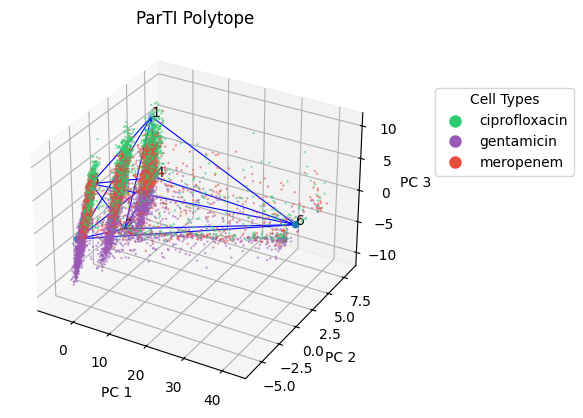

In [11]:
# Create a figure and an axes object
fig = plt.figure()
ax = plt.axes(projection='3d')

# Generate data for a 3D line plot

# Plot the 3D line
ax.scatter(arc_df["PC1"], arc_df["PC2"], arc_df["PC3"])

for i, label in enumerate([str(i+1) for i in range(mat_data["arc"].shape[0])]):
    ax.text(arc_df["PC1"][i], arc_df["PC2"][i], arc_df["PC3"][i], label)

filtered_df = pc_df
ax.scatter(filtered_df["PC1"],filtered_df["PC2"], filtered_df["PC3"], 
           color=[color_map[label] for label in meta_data.loc[:, "treatment"]], s=0.5, alpha=0.5)


# Draw lines connecting all pairs of archetype vertices
from itertools import combinations
arc_points = arc_df[["PC1", "PC2", "PC3"]].values
for i, j in combinations(range(len(arc_points)), 2):
    xs = [arc_points[i][0], arc_points[j][0]]
    ys = [arc_points[i][1], arc_points[j][1]]
    zs = [arc_points[i][2], arc_points[j][2]]
    ax.plot(xs, ys, zs, color='blue', linewidth=0.8)

# Add labels and title
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
plt.title('ParTI Polytope')

# Create custom legend handles
legend_elements = [Line2D([0], [0], marker='o', color='w', label=label,
                           markerfacecolor=color_map[label], markersize=10)
                   for label in unique_labels ]

# Add the legend to the plot
ax.legend(handles=legend_elements, title="Cell Types", loc='upper left', 
          bbox_to_anchor=(1, 1), borderaxespad=4)

# Show the plot
plt.show()

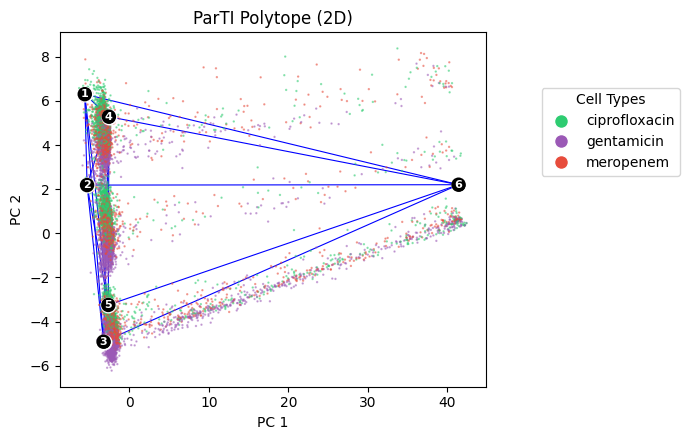

In [12]:
# Create a figure and an axes object for 2D plot
fig, ax = plt.subplots(figsize=(7, 4.5))

# Plot all data points colored by treatment (small dots)
filtered_df = pc_df
ax.scatter(
    filtered_df["PC1"], 
    filtered_df["PC2"], 
    color=[color_map[label] for label in meta_data.loc[:, "treatment"]], 
    s=0.5, alpha=0.5, zorder=2
)

# Plot archetype points in 2D (PC1 vs PC2) as large black circles
ax.scatter(
    arc_df["PC1"], 
    arc_df["PC2"], 
    s=100, color='black', edgecolor='white', linewidth=1.5, zorder=3
)

# Annotate archetype points with numbers (centered, white text in black circle)
for i, (x, y) in enumerate(zip(arc_df["PC1"], arc_df["PC2"])):
    ax.text(
        x, y, str(i+1), 
        fontsize=8, fontweight='bold', ha='center', va='center', 
        color='white', zorder=4,
        bbox=dict(facecolor='black', edgecolor='none', boxstyle='circle,pad=0.2')
    )

# Draw lines connecting all pairs of archetype vertices in 2D
from itertools import combinations
arc_points_2d = arc_df[["PC1", "PC2"]].values
for i, j in combinations(range(len(arc_points_2d)), 2):
    xs = [arc_points_2d[i][0], arc_points_2d[j][0]]
    ys = [arc_points_2d[i][1], arc_points_2d[j][1]]
    ax.plot(xs, ys, color='blue', linewidth=0.8, zorder=1)

# Add labels and title
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
plt.title('ParTI Polytope (2D)')

# Create custom legend handles
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=label,
           markerfacecolor=color_map[label], markersize=10)
    for label in unique_labels
]

# Add the legend to the plot
ax.legend(
    handles=legend_elements, title="Cell Types", loc='upper left', 
    bbox_to_anchor=(1, 1), borderaxespad=4
)

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

# t-ratio calculation

In [13]:
#arc_Df is the archetype coiordiantes in PC space 
archetypes_latent = arc_df.values
#pc_df is the data points in PC space

#computing simplex volume (consistent with MIDAA)
from math import factorial

#structure matches ParTI method of calculating the volume in latent space

ref = archetypes_latent[-1] #using last archetype coordinates as reference
edge_vectors = (archetypes_latent[:-1] - ref).T #calculates the edge vectors of the simplex

simplex_volume = np.abs(np.linalg.det(edge_vectors)) / factorial(archetypes_latent.shape[0] - 1) #same method as ParTI for calculating the volume of the simplexin n-dimensional space
print("Simplex Volume: ", simplex_volume)


Simplex Volume:  12538.335765124408


Given the polytope was only generated on the PC space of archetypes -1 , need to only take the first 5 PC dimensions for the complex hull volume

In [ ]:
import numpy as np
from scipy.spatial import ConvexHull


# Determine target dimension
num_archetypes = 6  # or arc_df.shape[0]
d = num_archetypes - 1

# Reduce to first d PCs and clean up
X = pc_df.iloc[:, :d].to_numpy()
X = np.unique(X, axis=0)  # drop duplicates

# Compute hull in low dimension with jitter to avoid precision issues
hull = ConvexHull(X, qhull_options='QJ')
convex_hull_volume = hull.volume
print("Convex Hull Volume:", convex_hull_volume)

Convex Hull Volume: 568545.3773192947


In [15]:
t_ratio = simplex_volume / convex_hull_volume
print("t-ratio: ", t_ratio)

t-ratio:  0.02205335979380039


# Distanced based analysis
I leveraged code developed previously for the ParTI algorithm by the DAL lab (Eppinger 2025) for these pipelines. The enable visual access to the benefits of the continuous representation that archetypal analysis provides over clustering techniques.

Distances are calculated in latent space

Eppinger's github used as basis of pipeline: https://github.com/ariaepp/dal-parti-tutorial

### Compute Distances to Archetypes

In [ ]:
def create_distance_matrix(meta_data, mat_data):
    """
    Creates a distance matrix from ParTI results.
    """
    import pandas as pd
    import numpy as np
    from scipy.spatial import distance
    
    # Fix the index issue - create proper cell IDs
    cell_ids = [f"Cell_{i:06d}" for i in range(len(meta_data))]
    meta_data_fixed = meta_data.copy()
    meta_data_fixed.index = cell_ids
    
    # Create the data structures with proper indices
    pc_df = pd.DataFrame(
        mat_data["pc"], 
        columns=[f"PC{i+1}" for i in range(mat_data["pc"].shape[-1])], 
        index=cell_ids
    )
    
    arc_df = pd.DataFrame(
        mat_data["arc"], 
        columns=[f"PC{i+1}" for i in range(mat_data["arc"].shape[-1])],
        index=[f"{i+1}" for i in range(mat_data["arc"].shape[0])]
    )
    
    # Calculate distances
    distance_df = pd.DataFrame(
        columns=[f"{i+1}" for i in range(mat_data["arc"].shape[0])], 
        index=cell_ids
    )
    
    pc_array = pc_df.values
    arc_array = arc_df.values
    
    for pc in range(arc_array.shape[0]):
        distances = distance.cdist(
            pc_array[:, 0:arc_df.shape[1]], 
            arc_array[pc:pc+1], 
            metric='euclidean'
        ).flatten()
        distance_df[f'{pc + 1}'] = distances
    
    # Merge with metadata (now with proper indices)
    combined_df = pd.merge(distance_df, meta_data_fixed, left_index=True, right_index=True)
    
    return combined_df, distance_df, pc_df, arc_df

# Then use it:
combined_df, distance_df, pc_df, arc_df = create_distance_matrix(meta_data, mat_data)

In [17]:
combined_df.head()

,1,2,3,4,5,6,treatment,replicate,replicate_treatment
Cell_000000,17.434918,19.339491,12.926550,12.330194,1.854498,44.300190,meropenem,Replicate2,Replicate2_meropenem
Cell_000001,20.849998,21.194772,15.119548,5.615105,10.294762,43.936010,meropenem,Replicate1,Replicate1_meropenem
Cell_000002,17.204879,18.934519,15.109657,2.789214,12.369802,44.522361,meropenem,Replicate1,Replicate1_meropenem
Cell_000003,17.953954,21.715840,13.136687,7.502879,10.844338,44.048502,meropenem,Replicate1,Replicate1_meropenem
Cell_000004,16.707489,19.465268,14.936199,3.721317,12.904259,44.637314,meropenem,Replicate1,Replicate1_meropenem


## 2) Density of Cells based on Distance to Each Archetype

Here, we can look at the density of cells as a function of distance from one archetype. Basically, this allows us to consider the cells in a more continuous manner as we transtion from near the archetyoe to elsewhere in space.

In [ ]:
def density_from_archtype(arc, treatments, c=None):
    '''
    Makes a density plot for all conditions based on distance to one archetype.
    '''
    if isinstance(treatments, str):
        treatments = [treatments]
    num_treatments = len(treatments)
    if c is None:
        # Use matplotlib default color cycle if not provided
        import itertools
        color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
        c = [color_cycle[i % len(color_cycle)] for i in range(num_treatments)]
    plt.figure(figsize=(8, 5))
    for i, treatment in enumerate(treatments):
        mask = combined_df["treatment"] == treatment
        # Use the correct column for the given archetype
        col = str(arc)
        if col in combined_df.columns:
            data = combined_df.loc[mask, col]
        else:
            # Fallback to the second column if not found (legacy behavior)
            data = combined_df.loc[mask].iloc[:, 1]
        plt.hist(data, bins=10, color=c[i], alpha=0.5, label=str(treatment))
    plt.title(f'Density from Archetype {arc} for all treatments')
    plt.xlabel('Distance from Archetype')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

In [ ]:
def density_from_archtype_multiple_conditions(arc, treatment, c=None):
    '''
    Makes a density plot for multiple condition based on distance to one archetype
    '''
    num_treatments = len(treatment)
    if not c:
        c = ['#1f77b4'] * num_treatments
            
    fig, axes = plt.subplots(num_treatments, 1, sharey=True, figsize=(8, num_treatments * 5))

    #handle case where there is only one condition
    if num_treatments == 1:
        axes = [axes]
    
    for i, cond in enumerate(treatments):
        ax = axes[i]
        ax.hist(combined_df[combined_df["treatment"] == cond].iloc[:, 1], bins=10, color=c[i])
        ax.set_title(f'Distance from Archetype {arc} for {cond}')
        ax.set_xlabel('Distance from Archetype')
        ax.set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_density_by_arch_distance_multiple_conditions(combined_df, num_arch, treatments, c=None):
    '''
    Makes a density plots (one plot per archetype). All treatments are plotted
    '''
    num_treatments = len(treatments)
    if not c:
        c = ['#1f77b4'] * num_treatments
    
    # two columns plot
    ncols = 2
    nrows = (num_arch) // ncols if num_arch % 2 == 0 else (num_arch) // ncols + 1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 5), sharey=True)
    
    # Flatten axes to make indexing easier
    axes = axes.flatten()
    
    for i in range(1, num_arch + 1):
        ax = axes[i - 1]  # axes indicies are one off
        
        # Plot for each condition on the same subplot
        for j, treatment in enumerate(treatments):
            n, x = np.histogram(combined_df[combined_df["treatment"] == treatment].loc[:, str(i)], bins=10, density=True)
            bin_centers = 0.5 * (x[1:] + x[:-1])
            ax.plot(bin_centers, n, linestyle='-', label=treatment, color=c[j])
        
        # Set titles and labels for each subplot
        ax.set_title(f"Distance from Archetype {i}")
        ax.set_xlabel("Distance from Archetype")
        ax.set_ylabel("Density")
        ax.legend(title="treatment")

    # Hide any empty subplots, this occurs if the num_arch is odd
    for i in range(num_arch, len(axes)):
        axes[i].axis('off')
    
    # Adjust layout to avoid overlapping
    plt.tight_layout()
    plt.show()

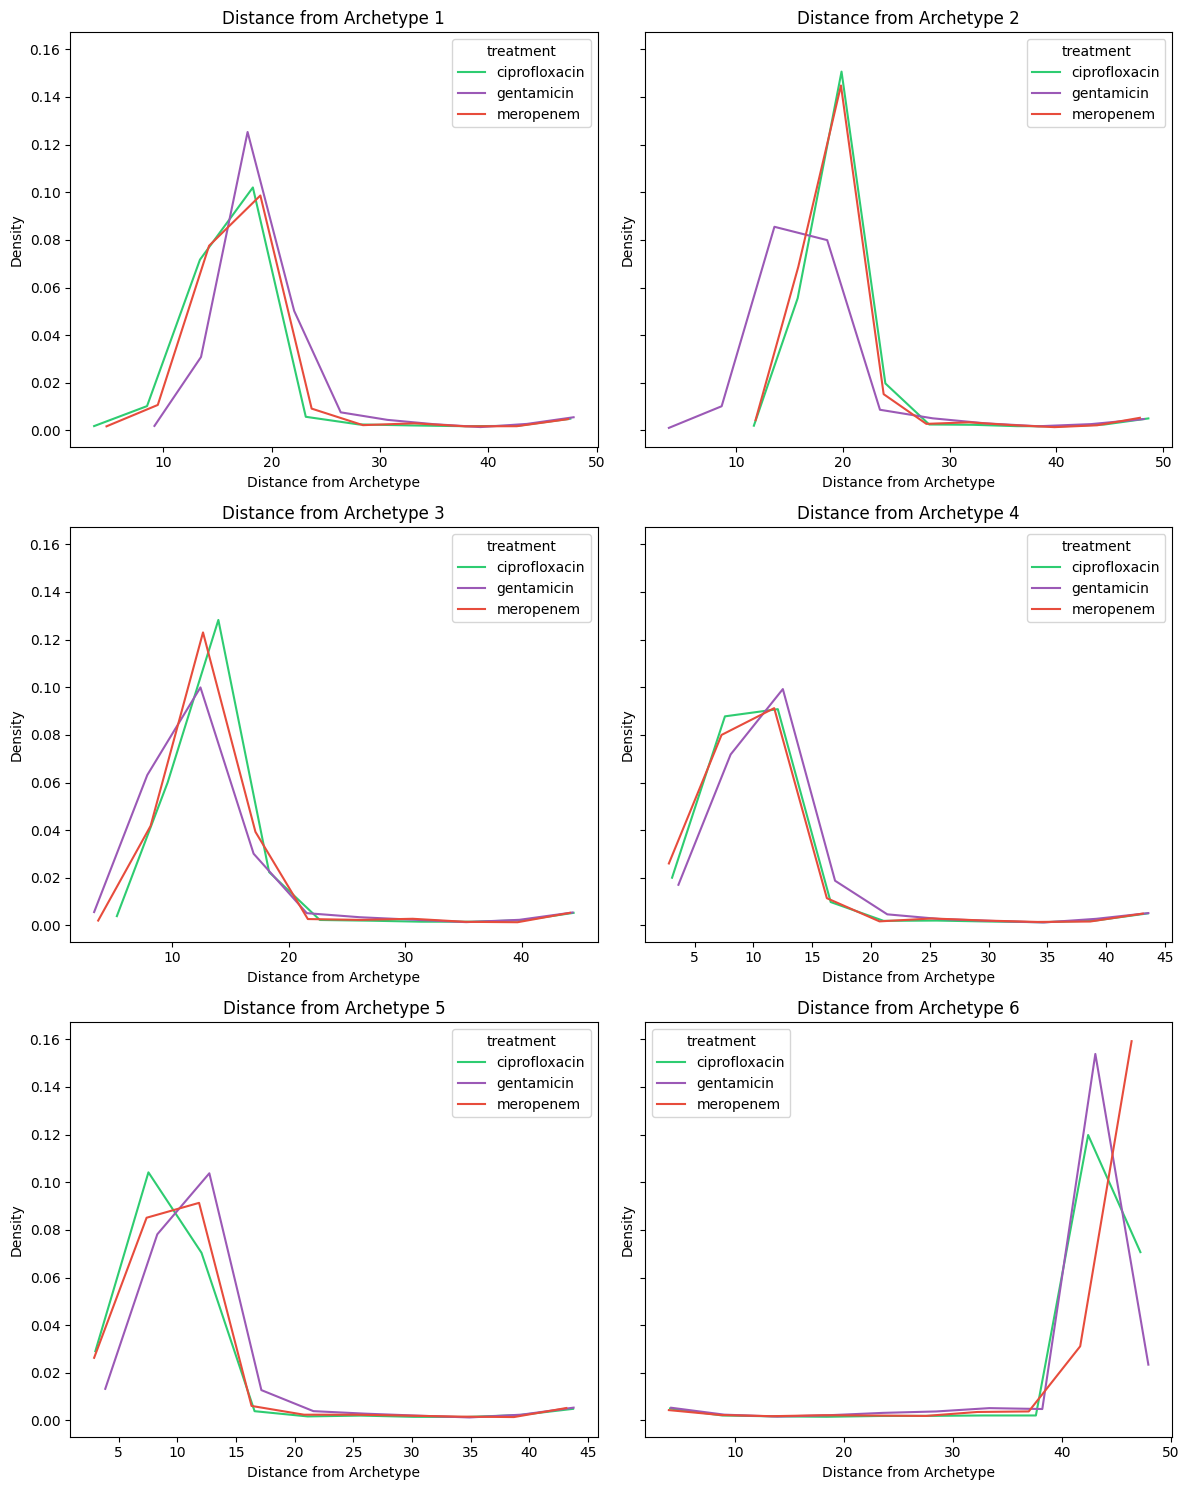

In [21]:
plot_density_by_arch_distance_multiple_conditions(combined_df, num_arch=6, 
                                                  treatments=sorted(color_map.keys()), 
                                                  c=[color_map[key] for key in sorted(color_map.keys())])

#3) Density of marker genes along transition instead 
Marker genes are defined by the bacdrop paper 

## 3) Density of Cells along the Transition from One Archetype to Another

Here, we can look at the density of each condition as we transition from one archetype to another archetype. Compared to above, we are now moving through the space from one archetype to proximal to another archtype. 

In [ ]:
def plot_density_transition_multiple_conditions(arch, num_arch, treatments, c=None):
    num_treatments = len(treatments)
    if not c:
        c = ['#1f77b4'] * num_treatments
    
    # two columns plot
    ncols = 2
    nrows = (num_arch-1) // ncols if (num_arch-1) % 2 == 0 else (num_arch-1) // ncols + 1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 5), sharey=True)
    
    # Flatten axes to make indexing easier
    axes = axes.flatten()

    arch_to_plot = list(range(1, num_arch+1))
    arch_to_plot.remove(arch)
    
    for i, a in enumerate(arch_to_plot):
        ax = axes[i]  # axes indicies are one off
        
        # Plot for each condition on the same subplot
        for j, treatment in enumerate(treatments):
            subset = combined_df[combined_df["treatment"] == treatment]
            n, x = np.histogram(np.log(np.log(subset.loc[:, str(arch)])) - np.log(subset.loc[:, str(a)]), bins=10, density=True)
            bin_centers = 0.5 * (x[1:] + x[:-1])
            ax.plot(bin_centers, n, linestyle='-',label=treatment, color=c[j])
        
        # Set titles and labels for each subplot   
        ax.set_title(f"Ratio of Distance from Archetype {arch} to {a}")
        ax.set_xticks([bin_centers[0], bin_centers[-1]], [f'Arch {arch}', f'Arch {a}'])
        ax.set_ylabel("Density")
        ax.legend(title="Treatment")

    # Hide any empty subplots, this occurs if the num_arch is odd
    for i in range(num_arch-1, len(axes)):
        axes[i].axis('off')
    
    # Adjust layout to avoid overlapping
    plt.tight_layout()
    plt.show()


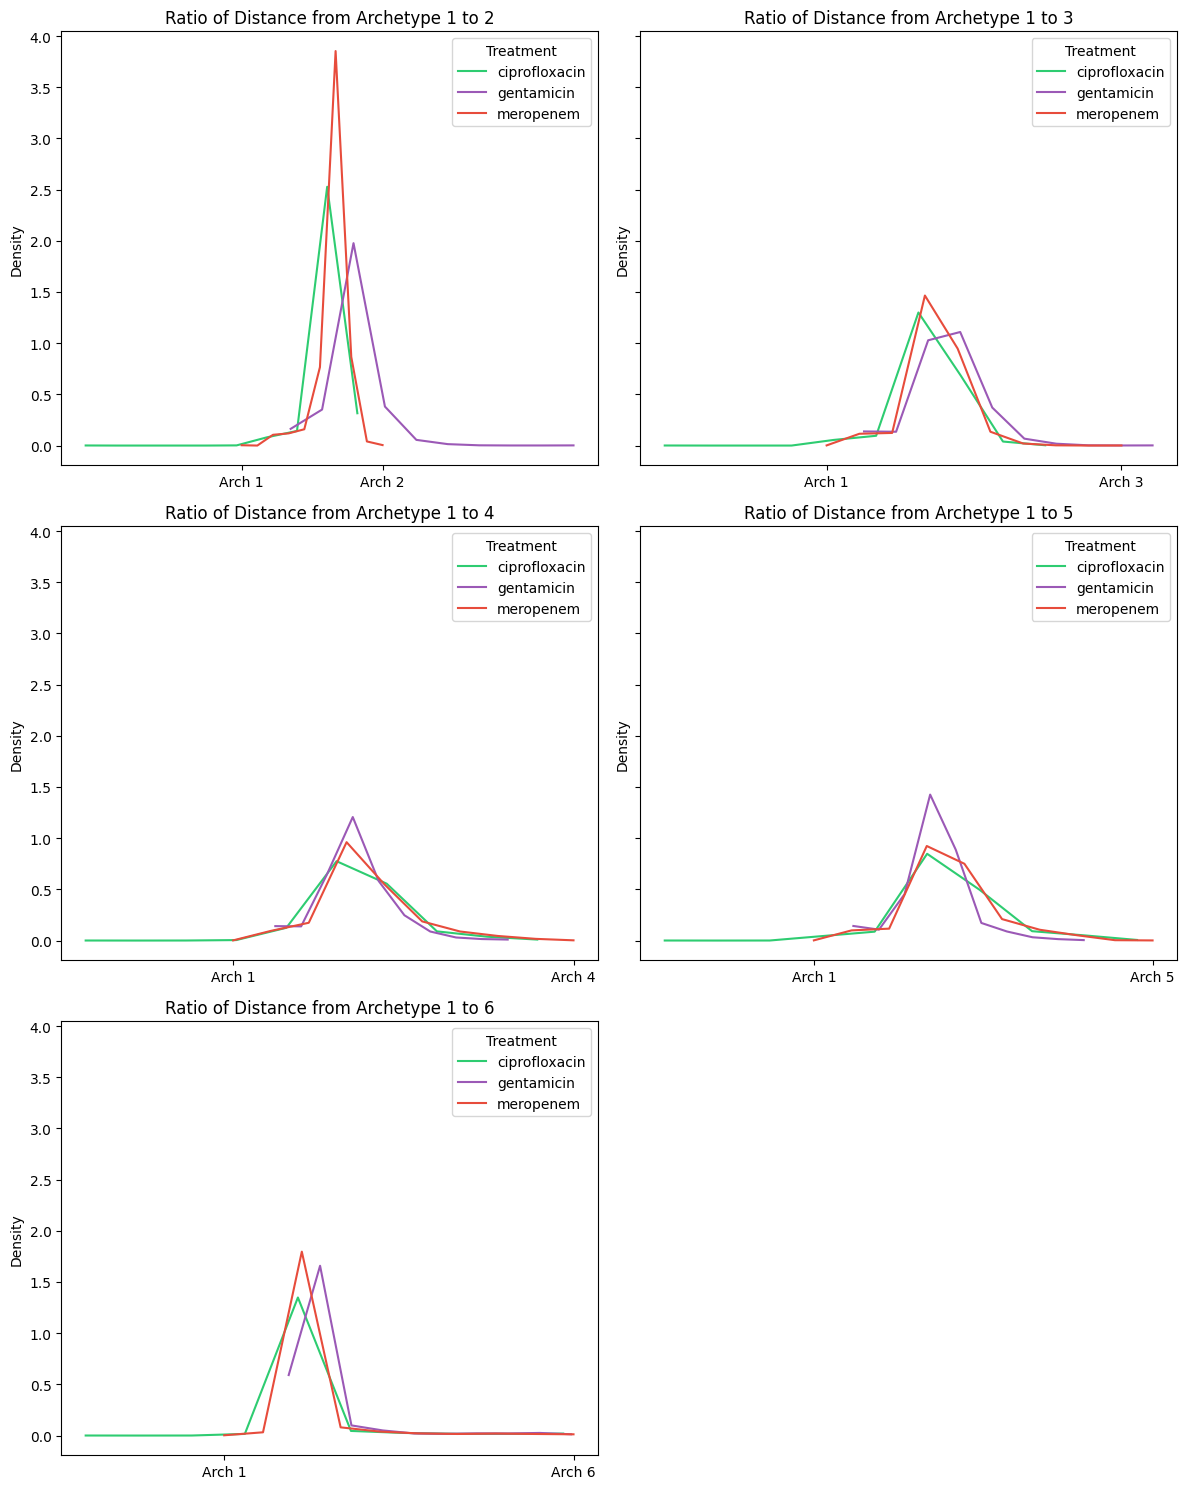

In [ ]:
plot_density_transition_multiple_conditions(
    arch=1,
    num_arch=num_archetypes,
    treatments=["ciprofloxacin", "gentamicin", "meropenem"],
    c=[color_map[key] for key in ["ciprofloxacin", "gentamicin", "meropenem"]]
)

## Visualing relative gene contribution to arhcetypes based on MIDAA analysis

Leverage the arcOrig matrix in the .mat file, which has archetype weighted by genes (arc x genes). Requires some preprocessing to add archetype and gene labels for analysis. Initial analysis identified one gene was dropped in ParTI pre-processing, cds-WP-032430145.1 - due to 0 variance across all samples
 
 

In [ ]:

import pandas as pd
import numpy as np
import scipy.io as sio

def label_arcOrig_matrix(arcOrig_matrix, gene_names_file_path, missing_gene="cds-WP-032430145.1"):
    # """
    # Simple function to label arcOrig matrix with proper row and column names.
    
    # Parameters:
    # - arcOrig_matrix: numpy array from ParTI output
    # - gene_names_file_path: path to the gene names file
    # - missing_gene: the gene that was dropped during processing (default: cds-WP-032430145.1)
    
    # Returns:
    # - pandas DataFrame with archetype numbers as row labels and gene names as column labels
    # """
    
    # Load gene names
    with open(gene_names_file_path, 'r') as f:
        gene_names = [line.strip() for line in f if line.strip()]
    
    # Convert to DataFrame
    arcOrig_df = pd.DataFrame(arcOrig_matrix)
    
    # Find the missing gene and create the correct gene list
    if missing_gene in gene_names:
        missing_gene_index = gene_names.index(missing_gene)
        # Remove the missing gene from the list
        selected_gene_names = gene_names[:missing_gene_index] + gene_names[missing_gene_index + 1:]
    else:
        # If missing gene not found, use truncation
        selected_gene_names = gene_names[:arcOrig_df.shape[1]]
    
    # Set column names (genes)
    if len(selected_gene_names) == arcOrig_df.shape[1]:
        arcOrig_df.columns = selected_gene_names
    else:
        # Fallback: use first N genes
        arcOrig_df.columns = selected_gene_names[:arcOrig_df.shape[1]]
    
    # Set row names (archetypes)
    arcOrig_df.index = [f"Archetype_{i+1}" for i in range(arcOrig_df.shape[0])]
    
    return arcOrig_df

def load_and_label_arcOrig(mat_file_path, gene_names_file_path, missing_gene="cds-WP-032430145.1"):
    """
    Load arcOrig from .mat file and label it properly.
    
    Parameters:
    - mat_file_path: path to the .mat file
    - gene_names_file_path: path to the gene names file
    - missing_gene: the gene that was dropped during processing
    
    Returns:
    - pandas DataFrame with proper labels
    """
    
    # Load the .mat file
    mat_data = sio.loadmat(mat_file_path)
    arcOrig_matrix = mat_data["arcOrig"]
    
    # Label the matrix
    labeled_arcOrig = label_arcOrig_matrix(arcOrig_matrix, gene_names_file_path, missing_gene)
    
    return labeled_arcOrig


In [25]:
arcOrig_matrix = mat_data["arcOrig"]
labeled_arcOrig = label_arcOrig_matrix(arcOrig_matrix, gene_names_file_path)
labeled_arcOrig.head()

,cds-AF52-RS00165,cds-AF52-RS00180,cds-AF52-RS00620,cds-AF52-RS01000,cds-AF52-RS01010,cds-AF52-RS01015,cds-AF52-RS01020,cds-AF52-RS01025,cds-AF52-RS01030,cds-AF52-RS01075,...,cds-WP-014228914.1,cds-WP-021441383.1,cds-WP-023301518.1,cds-WP-032426563.1,cds-WP-032429414.1,cds-WP-032429430.1,cds-WP-032429436.1,cds-WP-032429560.1,cds-WP-032429838.1,cds-WP-032429888.1
Archetype_1,-0.002457,0.017941,-0.126740,-0.001109,-0.004731,-0.001990,-0.010129,-0.003247,-0.001929,0.014439,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Archetype_2,-0.001542,-0.004428,0.089845,-0.001742,-0.005380,0.006342,-0.008204,-0.004426,-0.002633,0.005312,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Archetype_3,0.000757,0.004728,-0.117006,-0.004484,-0.001151,0.000293,-0.000062,-0.000474,-0.000267,0.008567,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Archetype_4,0.000293,-0.002165,0.032113,0.004876,0.003199,0.007519,0.004005,0.000950,0.000428,-0.000056,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Archetype_5,0.000693,0.014829,0.078236,0.000737,-0.000135,-0.003873,0.000886,0.000828,0.000022,0.006173,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In order to create comparative analysis with MIDAA, z-score mean the matrix to identify differentially expressed genes rather than aboslute genes

In [40]:
arcOrig_zscore = (labeled_arcOrig - labeled_arcOrig.mean(axis=0)) / (labeled_arcOrig.std(axis=0) + 1e-8)#z-scores each column (gene) to identify 
arcOrig_zscore.head()

,cds-AF52-RS00165,cds-AF52-RS00180,cds-AF52-RS00620,cds-AF52-RS01000,cds-AF52-RS01010,cds-AF52-RS01015,cds-AF52-RS01020,cds-AF52-RS01025,cds-AF52-RS01030,cds-AF52-RS01075,...,cds-WP-014228914.1,cds-WP-021441383.1,cds-WP-023301518.1,cds-WP-032426563.1,cds-WP-032429414.1,cds-WP-032429430.1,cds-WP-032429436.1,cds-WP-032429560.1,cds-WP-032429838.1,cds-WP-032429888.1
Archetype_1,-0.976826,0.387029,-0.789157,-0.490417,-0.809140,-0.584656,-1.127246,-0.872908,-0.820254,0.568972,...,-0.662006,-0.662006,-0.662006,-0.662006,-0.662006,-0.662006,-0.662006,-0.662006,-0.662006,-0.662006
Archetype_2,0.180928,-0.905475,-0.097875,0.047824,-0.174440,0.491486,-0.357222,-0.124197,0.032260,0.055019,...,0.390149,0.390149,0.390149,0.390149,0.390149,0.390149,0.390149,0.390149,0.390149,0.390149
Archetype_3,-0.948235,-0.804425,-0.964814,-1.260439,-0.854914,-0.653508,-0.563233,-0.987773,-1.075249,-0.589115,...,-1.171635,-1.171635,-1.171635,-1.171635,-1.171635,-1.171635,-1.171635,-1.171635,-1.171635,-1.171635
Archetype_4,1.750934,-0.183052,-0.139083,1.775031,1.873192,1.763259,1.800543,1.788979,1.664852,0.865002,...,1.682566,1.682566,1.682566,1.682566,1.682566,1.682566,1.682566,1.682566,1.682566,1.682566
Archetype_5,-0.158522,1.805533,0.148252,-0.123085,-0.210392,-0.934754,0.046204,-0.018826,-0.335870,0.809637,...,-0.417188,-0.417188,-0.417188,-0.417188,-0.417188,-0.417188,-0.417188,-0.417188,-0.417188,-0.417188


In [ ]:
arcOrig_zscore.head()
labeled_arcOrig = arcOrig_zscore.copy()

In [ ]:
#  Load gene names
# with open(gene_names_file_path, 'r') as f:
#     gene_names = [line.strip() for line in f if line.strip()]

# # Remove the missing gene (cds-WP-032430145.1) that was dropped during processing
# missing_gene = "cds-WP-032430145.1"
# if missing_gene in gene_names:
#     missing_gene_index = gene_names.index(missing_gene)
#     selected_gene_names = gene_names[:missing_gene_index] + gene_names[missing_gene_index + 1:]
# else:
#     selected_gene_names = gene_names[:arcOrig_matrix.shape[1]]

# # Create labeled DataFrame
# labeled_arcOrig = pd.DataFrame(arcOrig_matrix)
# labeled_arcOrig.columns = selected_gene_names[:labeled_arcOrig.shape[1]]
# labeled_arcOrig.index = [f"Archetype_{i+1}" for i in range(labeled_arcOrig.shape[0])]

# print(f"Labeled matrix shape: {labeled_arcOrig.shape}")
# print(f"Archetypes: {list(labeled_arcOrig.index)}")



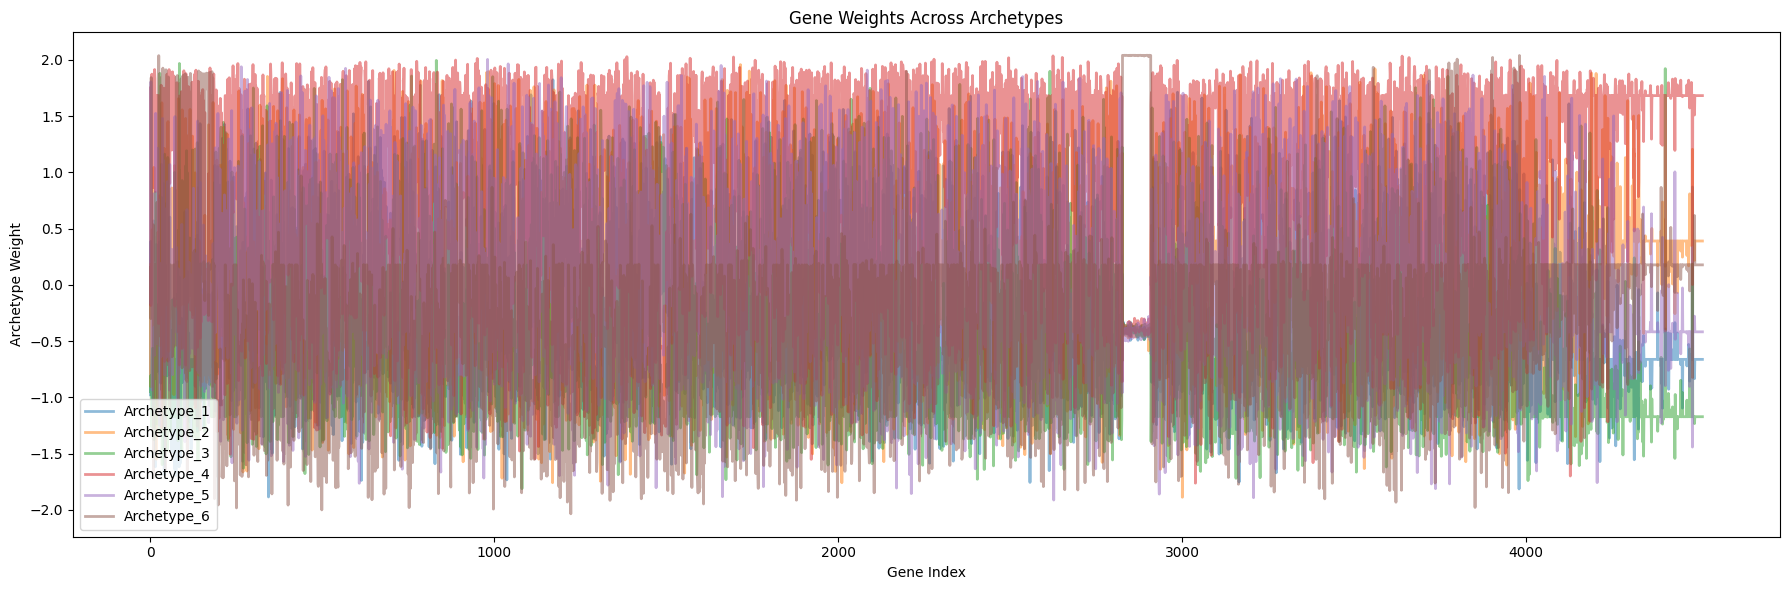

In [43]:
# Plot all genes (x: gene index, y: weight, lines: archetypes)
plt.figure(figsize=(18, 6))

for archetype in labeled_arcOrig.index:
    plt.plot(
        range(labeled_arcOrig.shape[1]), 
        labeled_arcOrig.loc[archetype].values, 
        label=archetype, 
        linewidth=2,
        alpha = 0.5
    )

plt.xlabel("Gene Index")
plt.ylabel("Archetype Weight")
plt.title("Gene Weights Across Archetypes")
plt.legend()
plt.tight_layout()
plt.show()


### Plotting all the gene expression changes per archetype

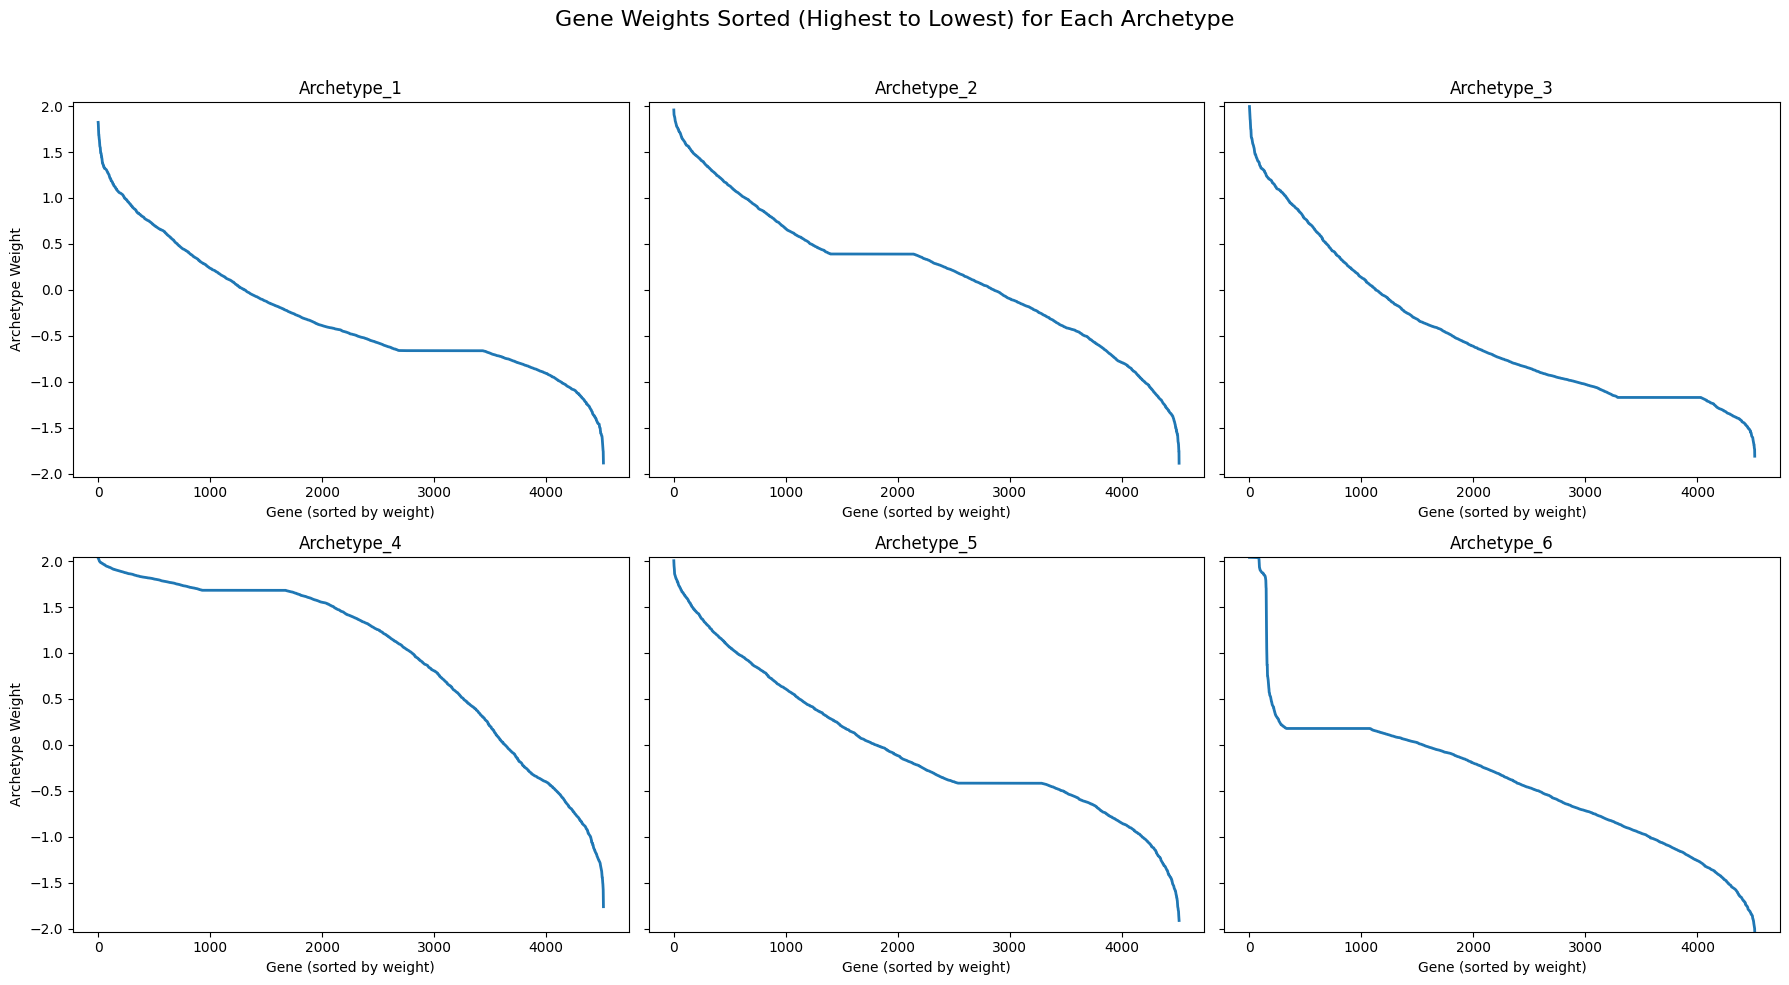

In [44]:
# For each archetype, plot the gene weights from highest to lowest (sorted), on separate subplots but in one image.
# Keep the y-axis the same across all subplots.

n_archetypes = len(labeled_arcOrig.index)
n_cols = min(3, n_archetypes)
n_rows = (n_archetypes + n_cols - 1) // n_cols

# Find global min and max for y-axis
global_min = labeled_arcOrig.min().min()
global_max = labeled_arcOrig.max().max()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharey=True)
axes = np.array(axes).reshape(-1)  # flatten in case of 1 row

for i, archetype in enumerate(labeled_arcOrig.index):
    ax = axes[i]
    sorted_weights = labeled_arcOrig.loc[archetype].sort_values(ascending=False)
    ax.plot(range(len(sorted_weights)), sorted_weights.values, linewidth=2)
    ax.set_title(f"{archetype}")
    ax.set_xlabel("Gene (sorted by weight)")
    if i % n_cols == 0:
        ax.set_ylabel("Archetype Weight")
    ax.set_ylim(global_min, global_max)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

fig.suptitle("Gene Weights Sorted (Highest to Lowest) for Each Archetype", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### PRINT SUMMARY OF TOP GENES

Processing Archetype_1...
Processing Archetype_2...
Processing Archetype_3...
Processing Archetype_4...
Processing Archetype_5...
Processing Archetype_6...


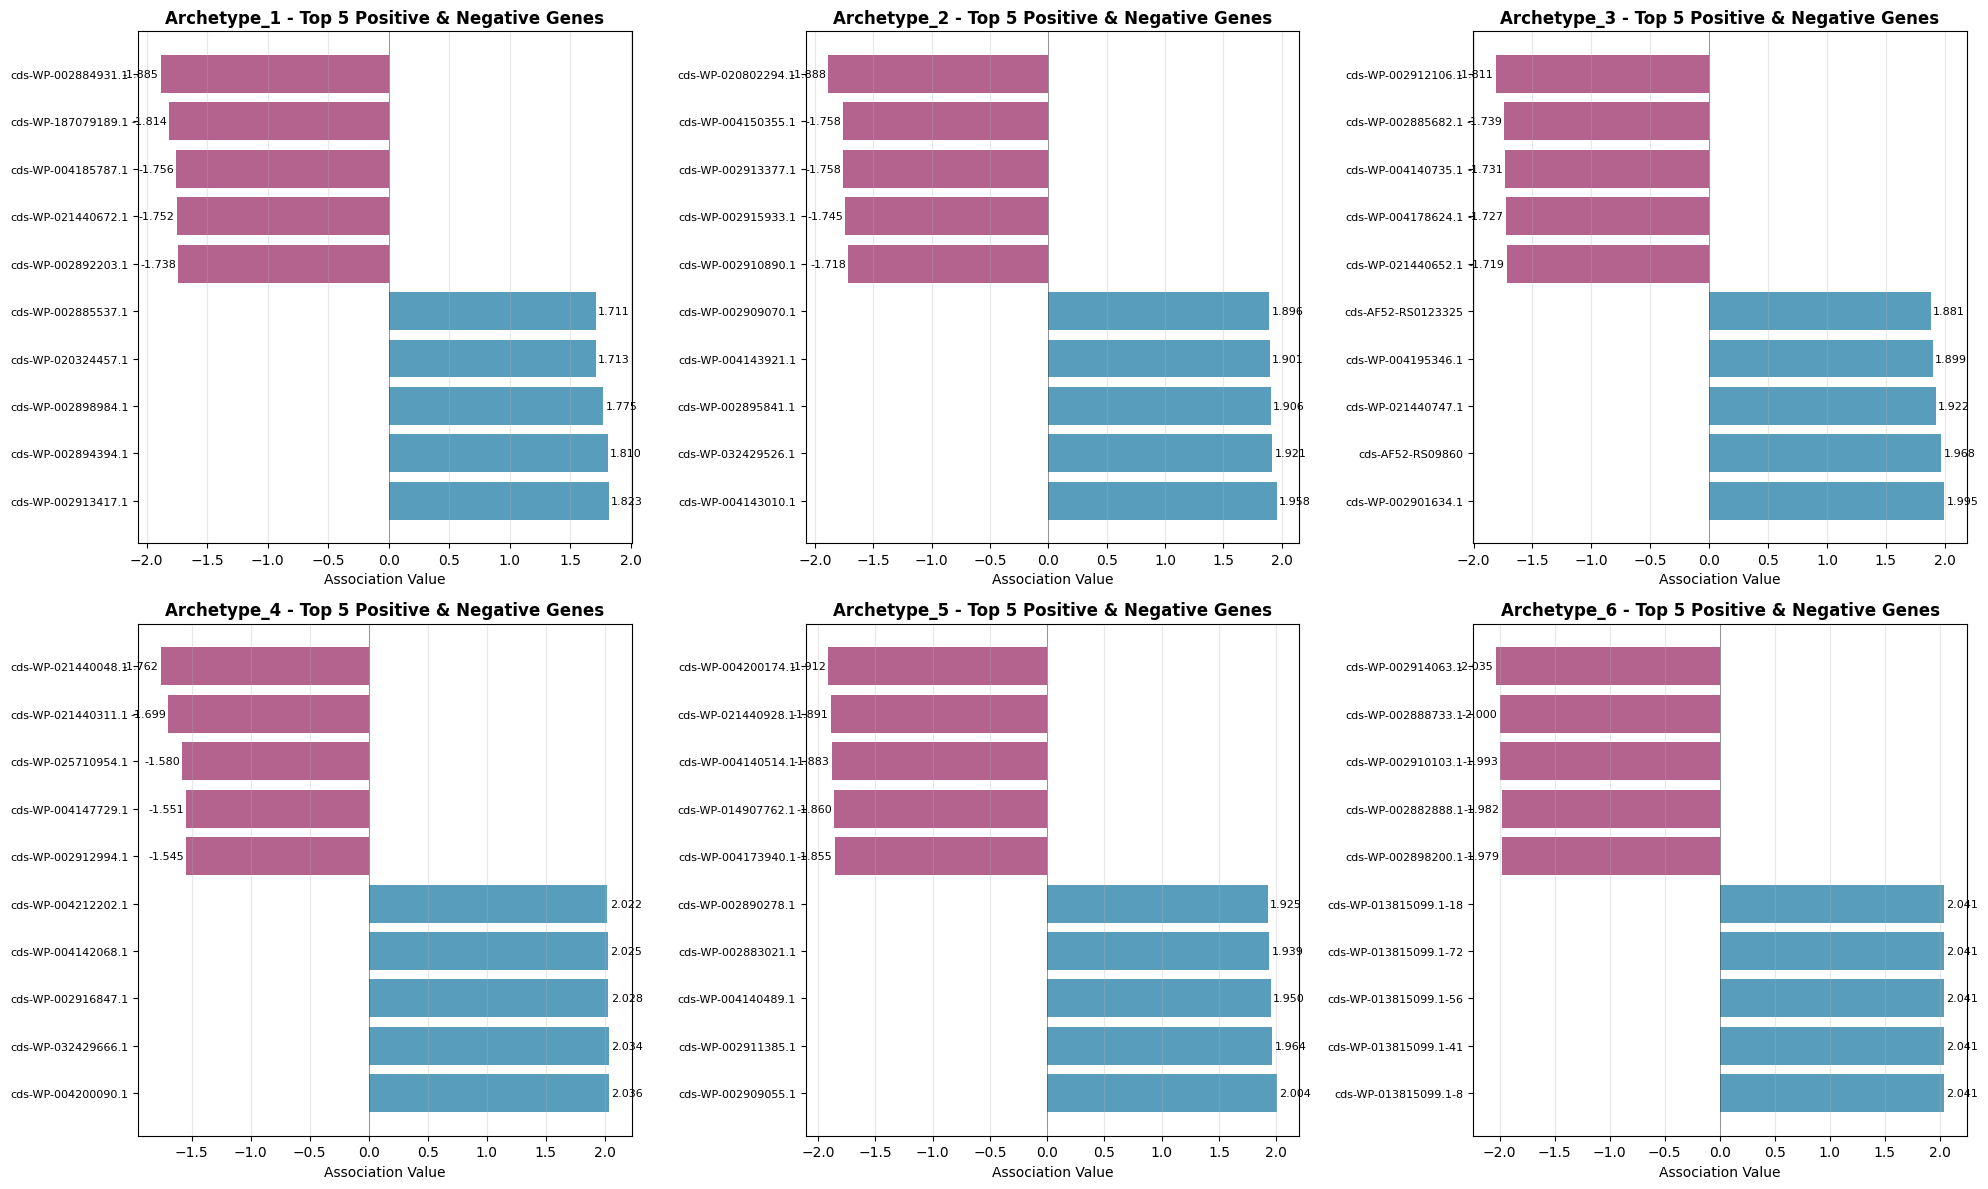

In [45]:
# PLOT TOP GENES FOR EACH ARCHETYPE
n_top = 5
n_archetypes = len(labeled_arcOrig.index)

# Create subplot grid
n_cols = 3
n_rows = (n_archetypes + 2) // 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
if n_archetypes == 1:
    axes = axes.reshape(1, -1)

# Flatten axes
axes = axes.flatten()

# Store results
archetype_results = {}

for i, archetype in enumerate(labeled_arcOrig.index):
    print(f"Processing {archetype}...")
    
    ax = axes[i]
    
    # Get gene values for this archetype
    archetype_values = labeled_arcOrig.loc[archetype]
    sorted_genes = archetype_values.sort_values(ascending=False)
    
    # Get top positive and negative genes
    top_positive = sorted_genes.head(n_top)
    top_negative = sorted_genes.tail(n_top)
    
    # Store results
    archetype_results[archetype] = {
        'positive': top_positive,
        'negative': top_negative
    }
    
    # Combine positive and negative for plotting
    all_top_genes = pd.concat([top_positive, top_negative])
    
    # Create colors (blue for positive, red for negative)
    colors = ['#2E86AB' if val >= 0 else '#A23B72' for val in all_top_genes.values]
    
    # Create horizontal bar plot
    bars = ax.barh(range(len(all_top_genes)), all_top_genes.values, 
                  color=colors, alpha=0.8)
    
    # Customize plot
    ax.set_yticks(range(len(all_top_genes)))
    ax.set_yticklabels(all_top_genes.index, fontsize=8)
    ax.set_xlabel('Association Value', fontsize=10)
    ax.set_title(f'{archetype} - Top {n_top} Positive & Negative Genes', 
                fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add vertical line at zero
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.5, linewidth=0.5)
    
    # Add value labels on bars
    for j, (bar, value) in enumerate(zip(bars, all_top_genes.values)):
        if value >= 0:
            ax.text(value + (abs(value) * 0.01), j, f'{value:.3f}', 
                   va='center', fontsize=8)
        else:
            ax.text(value - (abs(value) * 0.01), j, f'{value:.3f}', 
                   va='center', fontsize=8, ha='right')

# Hide empty subplots
for i in range(n_archetypes, len(axes)):
    axes[i].axis('off')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

### Mapping gene functinos
Using BacDrop provided maps of refseqidf to gene to function

In [ ]:
def load_gene_mapping_simple(mapping_file_path):
    """
    Load the gene mapping from BacDrop_gene_mapping.csv, takes into account the different formats of the gene IDs (hyphen and underscore)
    """
    mapping_df = pd.read_csv(mapping_file_path)
    
    # Create a dictionary for easy lookup
    gene_mapping = {}
    
    for _, row in mapping_df.iterrows():
        refseq_id = row['RefSeq_ID']
        gene_name = row['Gene']
        product = row['Product']
        
        # Store the mapping with both formats (hyphen and underscore)
        gene_mapping[refseq_id] = {
            'gene_name': gene_name,
            'product': product
        }
        
        # Also store with hyphen format for matching
        if refseq_id.startswith('cds-WP_'):
            hyphen_version = refseq_id.replace('cds-WP_', 'cds-WP-')
            gene_mapping[hyphen_version] = {
                'gene_name': gene_name,
                'product': product
            }
    
    return gene_mapping


In [ ]:
gene_mapping = load_gene_mapping_simple(r"path/to/BacDrop_gene_mapping.csv")

In [48]:
# This code plots top 5 positive and top 5 negative genes for each archetype
# WITH GENE MAPPING to convert gene IDs to readable names and tyheir associated functinos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio




# CREATE ANNOTATED TABLES
print("\n" + "="*80)
print("ANNOTATED GENE TABLES FOR EACH ARCHETYPE")
print("="*80)

for archetype, results in archetype_results.items():
    print(f"\n{archetype.upper()} - ANNOTATED GENE TABLE")
    print("="*60)
    
    # Create table for positive genes
    print("\nTOP 5 POSITIVE GENES:")
    print("-" * 60)
    print(f"{'RefSeq_ID':<25} | {'Gene Name':<20} | {'Product':<40}")
    print("-" * 60)
    
    for gene_id, value in results['positive'].items():
        
        #setting default if refseqID is not in the mapping
        gene_name = "Unknown"
        product = "Unknown" 
        
        if gene_id in gene_mapping:
            annotation = gene_mapping[gene_id] #fetching annotations fo rthe refseqID
            gene_name = annotation.get('gene_name', 'Unknown') #assigining gene name from annotation 
            product = annotation.get('product', 'Unknown') #assigining product from annotation
        
        print(f"{gene_id:<25} | {gene_name:<20} | {product:<40}") #formatting the output (widths)
    
    # Create table for negative genes
    print("\nTOP 5 NEGATIVE GENES:")
    print("-" * 60)
    print(f"{'RefSeq_ID':<25} | {'Gene Name':<20} | {'Product':<40}")
    print("-" * 60)
    
    for gene_id, value in results['negative'].items():
        gene_name = "Unknown"
        product = "Unknown"
        
        if gene_id in gene_mapping:
            annotation = gene_mapping[gene_id]
            gene_name = annotation.get('gene_name', 'Unknown')
            product = annotation.get('product', 'Unknown')
        
        print(f"{gene_id:<25} | {gene_name:<20} | {product[:40]:<40}")
    
    print()


ANNOTATED GENE TABLES FOR EACH ARCHETYPE

ARCHETYPE_1 - ANNOTATED GENE TABLE

TOP 5 POSITIVE GENES:
------------------------------------------------------------
RefSeq_ID                 | Gene Name            | Product                                 
------------------------------------------------------------
cds-WP-002913417.1        | mgrA                 | L-glyceraldehyde 3-phosphate reductase  
cds-WP-002894394.1        | ahpC                 | alkyl hydroperoxide reductase subunit C 
cds-WP-002898984.1        | mdtG                 | multidrug efflux MFS transporter MdtG   
cds-WP-020324457.1        | SulP                 | SulP family inorganic anion transporter 
cds-WP-002885537.1        | rsgA                 | small ribosomal subunit biogenesis GTPase RsgA

TOP 5 NEGATIVE GENES:
------------------------------------------------------------
RefSeq_ID                 | Gene Name            | Product                                 
-------------------------------------------

### Plotting expression of marker genes 
BacDrop identifed 3 key genes of related functino in the paper: recA, IS5-like and ibpB 

These viusalisations enable analysis of the extent to which the arhcetypes and latent space capture relationshisp across these marker genes

In [ ]:
#creating archetype df for easier analysis
genes_by_archetype = labeled_arcOrig.T
genes_by_archetype_df = pd.DataFrame(genes_by_archetype)
genes_by_archetype_df.head()
df_archetypes = genes_by_archetype_df

In [50]:
#adding gene names and functions to genes_by_arhcetype 
# For each RefSeq_ID in the index of df_archetypes, check if it exists in gene_mapping
df_archetypes['In_Gene_Mapping'] = df_archetypes.index.map(lambda refseq: refseq in gene_mapping)

#print summary of matches
num_matched = df_archetypes['In_Gene_Mapping'].sum()
num_total = len(df_archetypes)
print(f"{num_matched} out of {num_total} RefSeq_IDs in df_archetypes are found in gene_mapping.")

# Show the first few rows to verify
print(df_archetypes.head())

4218 out of 4513 RefSeq_IDs in df_archetypes are found in gene_mapping.
                  Archetype_1  Archetype_2  Archetype_3  Archetype_4  \
cds-AF52-RS00165    -0.976826     0.180928    -0.948235     1.750934   
cds-AF52-RS00180     0.387029    -0.905475    -0.804425    -0.183052   
cds-AF52-RS00620    -0.789157    -0.097875    -0.964814    -0.139083   
cds-AF52-RS01000    -0.490417     0.047824    -1.260439     1.775031   
cds-AF52-RS01010    -0.809140    -0.174440    -0.854914     1.873192   

                  Archetype_5  Archetype_6  In_Gene_Mapping  
cds-AF52-RS00165    -0.158522     0.151722            False  
cds-AF52-RS00180     1.805533    -0.299609            False  
cds-AF52-RS00620     0.148252     1.842678            False  
cds-AF52-RS01000    -0.123085     0.051085            False  
cds-AF52-RS01010    -0.210392     0.175694            False  


In [51]:
#add the gene names and product to the df_archetypesusing gene_mapping
def get_gene_name(refseq):
    if refseq in gene_mapping:
        return gene_mapping[refseq].get('gene_name', None)
    return None

def get_product(refseq):
    if refseq in gene_mapping:
        return gene_mapping[refseq].get('product', None)
    return None

df_archetypes['gene_name'] = df_archetypes.index.map(get_gene_name)
df_archetypes['product'] = df_archetypes.index.map(get_product)

# Optionally, show a preview
print(df_archetypes.head())


                  Archetype_1  Archetype_2  Archetype_3  Archetype_4  \
cds-AF52-RS00165    -0.976826     0.180928    -0.948235     1.750934   
cds-AF52-RS00180     0.387029    -0.905475    -0.804425    -0.183052   
cds-AF52-RS00620    -0.789157    -0.097875    -0.964814    -0.139083   
cds-AF52-RS01000    -0.490417     0.047824    -1.260439     1.775031   
cds-AF52-RS01010    -0.809140    -0.174440    -0.854914     1.873192   

                  Archetype_5  Archetype_6  In_Gene_Mapping gene_name product  
cds-AF52-RS00165    -0.158522     0.151722            False      None    None  
cds-AF52-RS00180     1.805533    -0.299609            False      None    None  
cds-AF52-RS00620     0.148252     1.842678            False      None    None  
cds-AF52-RS01000    -0.123085     0.051085            False      None    None  
cds-AF52-RS01010    -0.210392     0.175694            False      None    None  


Gene to RefSeq mapping used: {'recA': 'cds-WP-002914769.1', 'IS5-like': 'cds-WP-013815099.1', 'ibpB': 'cds-WP-004145074.1'}
Expression matrix shape: (0, 3)
Gene indices found: [1264, 2827, 1814]
Number of genes of interest: 3


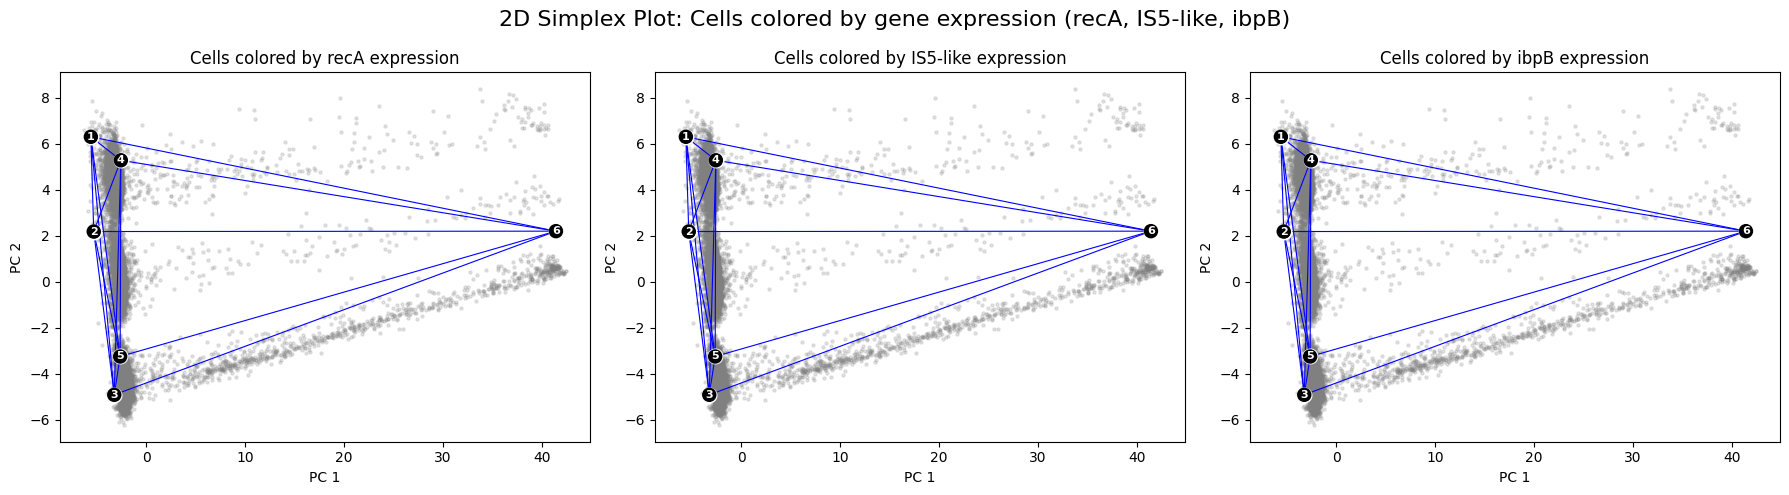

In [52]:
# Plot simplex and 2D scatter, coloring cells by expression of recA, IS5-like, and ibpB
# Uses helper function: simplex_plot to overlay the simplex

import matplotlib.pyplot as plt

filtered_df = pc_df

# 1. Map gene names to RefSeq IDs using df_archetypes
genes_of_interest = ['recA', 'IS5-like', 'ibpB']
gene_id_map = {}
for gene in genes_of_interest:
    matches = df_archetypes[df_archetypes['gene_name'].str.lower() == gene.lower()]
    if not matches.empty:
        gene_id_map[gene] = matches.index[0]
    else:
        print(f"Warning: Gene {gene} not found in df_archetypes.")

print("Gene to RefSeq mapping used:", gene_id_map)

# 2. Get indices of these genes in adata.var_names
gene_indices = []
for gene in genes_of_interest:
    refseq = gene_id_map.get(gene)
    if refseq is not None and refseq in adata.var_names:
        gene_indices.append(list(adata.var_names).index(refseq))
    else:
        print(f"Warning: RefSeq {refseq} for gene {gene} not found in adata.var_names.")

# 3. Extract expression for these genes from adata.X (cell x gene)
import numpy as np
expr_matrix = np.array(adata.X[:, gene_indices])

# 4. Prepare 2D coordinates for each cell in latent space
cell_coords_2d = pc_df[["PC1", "PC2"]].values  # shape: (n_cells, 2)
archetypes_latent_2d = arc_df[["PC1", "PC2"]].values  # shape: (n_archetypes, 2)


# 5. Plot: 2D scatter, colored by each gene's expression, and overlay simplex
fig = plt.figure(figsize=(18, 5))

# Debug: Print the shapes and content to understand what's happening
print(f"Expression matrix shape: {expr_matrix.shape}")
print(f"Gene indices found: {gene_indices}")
print(f"Number of genes of interest: {len(genes_of_interest)}")

for gene_idx, gene in enumerate(genes_of_interest):
    ax = fig.add_subplot(1, 3, gene_idx+1)
    
    # Plot the cells, colored by gene expression
    from matplotlib.colors import LinearSegmentedColormap

    # Create a custom colormap: light purple -> yellow-green -> vibrant green
    custom_cmap = LinearSegmentedColormap.from_list(
        "custom_viridis_gradient",
        [
            (0.0, "#e0bbff"),   # very light purple
            (0.4, "#baffc9"),  # light yellow-green
            (0.7, "#39ff14"),  # neon green (very vibrant)
            (1.0, "#008f11"),  # deep vibrant green
        ]
    )

    # Check if we have expression data for this gene and it's not empty
    if (gene_idx < len(gene_indices) and 
        gene_idx < expr_matrix.shape[1] and 
        expr_matrix.shape[1] > 0 and 
        not np.all(np.isnan(expr_matrix[:, gene_idx]))):
        
        # Get the expression values for this gene
        gene_expr = expr_matrix[:, gene_idx]
        
        # Remove any NaN values and get valid indices
        valid_mask = ~np.isnan(gene_expr)
        valid_coords = cell_coords_2d[valid_mask]
        valid_expr = gene_expr[valid_mask]
        
        if len(valid_expr) > 0:
            sc = ax.scatter(
                valid_coords[:, 0], valid_coords[:, 1],
                c=valid_expr, cmap=custom_cmap, s=5, alpha=0.2
            )
        else:
            # Fallback: plot all cells in gray if no valid expression data
            sc = ax.scatter(
                cell_coords_2d[:, 0], cell_coords_2d[:, 1],
                c='gray', s=5, alpha=0.2
            )
    else:
        # Fallback: plot cells without coloring if no expression data
        sc = ax.scatter(
            cell_coords_2d[:, 0], cell_coords_2d[:, 1],
            c='gray', s=5, alpha=0.2
        )
    
    # Draw the simplex lines (same approach as Cell 14)
    from itertools import combinations
    arc_points_2d = arc_df[["PC1", "PC2"]].values
    for j, k in combinations(range(len(arc_points_2d)), 2):
        xs = [arc_points_2d[j][0], arc_points_2d[k][0]]
        ys = [arc_points_2d[j][1], arc_points_2d[k][1]]
        ax.plot(xs, ys, color='blue', linewidth=0.8, zorder=1)
    
    # Plot archetype points as large black circles
    ax.scatter(
        arc_df["PC1"], 
        arc_df["PC2"], 
        s=100, color='black', edgecolor='white', linewidth=1.5, zorder=3
    )
    
    # Annotate archetype points with numbers
    for arch_idx, (x, y) in enumerate(zip(arc_df["PC1"], arc_df["PC2"])):
        ax.text(
            x, y, str(arch_idx+1), 
            fontsize=8, fontweight='bold', ha='center', va='center', 
            color='white', zorder=4,
            bbox=dict(facecolor='black', edgecolor='none', boxstyle='circle,pad=0.2')
        )
    
    ax.set_title(f"Cells colored by {gene} expression")
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    
    # Only add colorbar if we have valid expression data
    if (gene_idx < len(gene_indices) and 
        gene_idx < expr_matrix.shape[1] and 
        expr_matrix.shape[1] > 0 and 
        not np.all(np.isnan(expr_matrix[:, gene_idx])) and
        len(valid_expr) > 0):
        plt.colorbar(sc, ax=ax, shrink=0.6, label=f"{gene} expression")

fig.suptitle("2D Simplex Plot: Cells colored by gene expression (recA, IS5-like, ibpB)", fontsize=16)
plt.tight_layout()
plt.show()


Gene to RefSeq mapping used: {'recA': 'cds-WP-002914769.1', 'IS5-like': 'cds-WP-013815099.1', 'ibpB': 'cds-WP-004145074.1'}
Expression matrix shape: (0, 3)
Gene indices found: [1264, 2827, 1814]
Number of genes of interest: 3


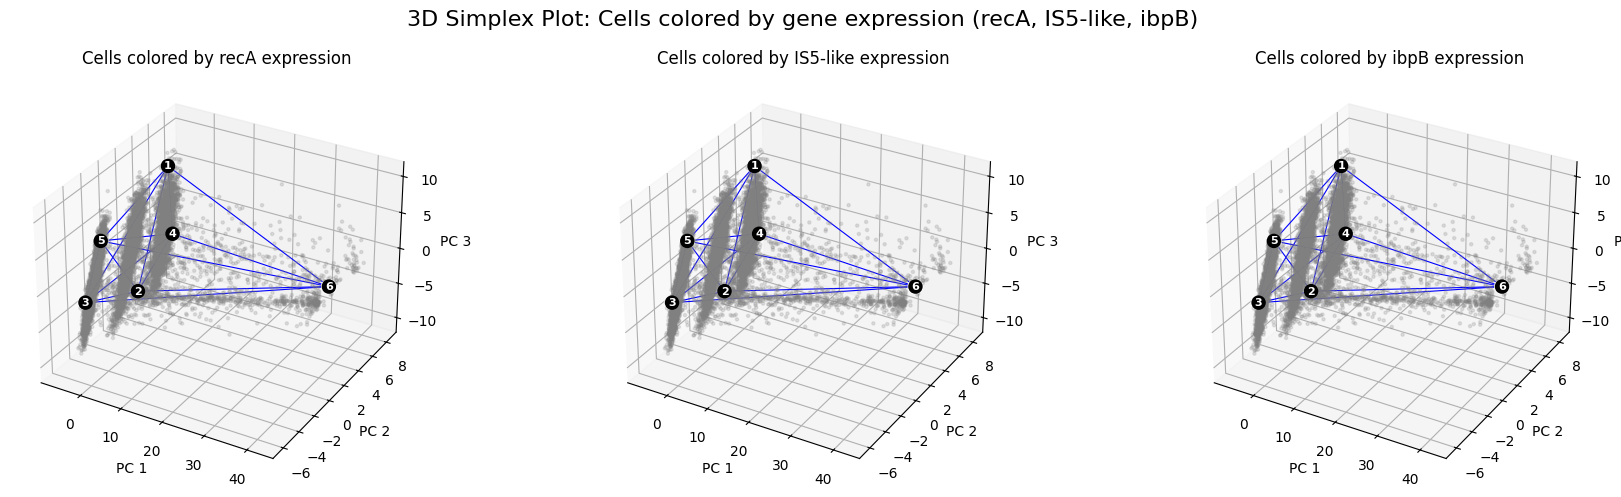

In [53]:
# Plot simplex and 3D scatter, coloring cells by expression of recA, IS5-like, and ibpB
# Uses helper function: simplex_plot to overlay the simplex

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import

filtered_df = pc_df

# 1. Map gene names to RefSeq IDs using df_archetypes
genes_of_interest = ['recA', 'IS5-like', 'ibpB']
gene_id_map = {}
for gene in genes_of_interest:
    matches = df_archetypes[df_archetypes['gene_name'].str.lower() == gene.lower()]
    if not matches.empty:
        gene_id_map[gene] = matches.index[0]
    else:
        print(f"Warning: Gene {gene} not found in df_archetypes.")

print("Gene to RefSeq mapping used:", gene_id_map)

# 2. Get indices of these genes in adata.var_names
gene_indices = []
for gene in genes_of_interest:
    refseq = gene_id_map.get(gene)
    if refseq is not None and refseq in adata.var_names:
        gene_indices.append(list(adata.var_names).index(refseq))
    else:
        print(f"Warning: RefSeq {refseq} for gene {gene} not found in adata.var_names.")

# 3. Extract expression for these genes from adata.X (cell x gene)
import numpy as np
expr_matrix = np.array(adata.X[:, gene_indices])

# 4. Prepare 3D coordinates for each cell in latent space
cell_coords_3d = pc_df[["PC1", "PC2", "PC3"]].values  # shape: (n_cells, 3)
archetypes_latent_3d = arc_df[["PC1", "PC2", "PC3"]].values  # shape: (n_archetypes, 3)

# 5. Plot: 3D scatter, colored by each gene's expression, and overlay simplex
fig = plt.figure(figsize=(18, 5))

# Debug: Print the shapes and content to understand what's happening
print(f"Expression matrix shape: {expr_matrix.shape}")
print(f"Gene indices found: {gene_indices}")
print(f"Number of genes of interest: {len(genes_of_interest)}")

for gene_idx, gene in enumerate(genes_of_interest):
    ax = fig.add_subplot(1, 3, gene_idx+1, projection='3d')
    
    # Plot the cells, colored by gene expression
    from matplotlib.colors import LinearSegmentedColormap

    # Create a custom colormap: light purple -> yellow-green -> vibrant green
    custom_cmap = LinearSegmentedColormap.from_list(
        "custom_viridis_gradient",
        [
            (0.0, "#e0bbff"),   # very light purple
            (0.4, "#baffc9"),  # light yellow-green
            (0.7, "#39ff14"),  # neon green (very vibrant)
            (1.0, "#008f11"),  # deep vibrant green
        ]
    )

    # Check if we have expression data for this gene and it's not empty
    if (gene_idx < len(gene_indices) and 
        gene_idx < expr_matrix.shape[1] and 
        expr_matrix.shape[1] > 0 and 
        not np.all(np.isnan(expr_matrix[:, gene_idx]))):
        
        # Get the expression values for this gene
        gene_expr = expr_matrix[:, gene_idx]
        
        # Remove any NaN values and get valid indices
        valid_mask = ~np.isnan(gene_expr)
        valid_coords = cell_coords_3d[valid_mask]
        valid_expr = gene_expr[valid_mask]
        
        if len(valid_expr) > 0:
            sc = ax.scatter(
                valid_coords[:, 0], valid_coords[:, 1], valid_coords[:, 2],
                c=valid_expr, cmap=custom_cmap, s=5, alpha=0.2
            )
        else:
            # Fallback: plot all cells in gray if no valid expression data
            sc = ax.scatter(
                cell_coords_3d[:, 0], cell_coords_3d[:, 1], cell_coords_3d[:, 2],
                c='gray', s=5, alpha=0.2
            )
    else:
        # Fallback: plot cells without coloring if no expression data
        sc = ax.scatter(
            cell_coords_3d[:, 0], cell_coords_3d[:, 1], cell_coords_3d[:, 2],
            c='gray', s=5, alpha=0.2
        )
    
    # Draw the simplex lines in 3D (all pairs of archetypes)
    from itertools import combinations
    arc_points_3d = arc_df[["PC1", "PC2", "PC3"]].values
    for j, k in combinations(range(len(arc_points_3d)), 2):
        xs = [arc_points_3d[j][0], arc_points_3d[k][0]]
        ys = [arc_points_3d[j][1], arc_points_3d[k][1]]
        zs = [arc_points_3d[j][2], arc_points_3d[k][2]]
        ax.plot(xs, ys, zs, color='blue', linewidth=0.8, zorder=1)
    
    # Plot archetype points as large black circles
    ax.scatter(
        arc_df["PC1"], 
        arc_df["PC2"], 
        arc_df["PC3"],
        s=100, color='black', edgecolor='white', linewidth=1.5, zorder=3
    )
    
    # Annotate archetype points with numbers
    for arch_idx, (x, y, z) in enumerate(zip(arc_df["PC1"], arc_df["PC2"], arc_df["PC3"])):
        ax.text(
            x, y, z, str(arch_idx+1), 
            fontsize=8, fontweight='bold', ha='center', va='center', 
            color='white', zorder=4,
            bbox=dict(facecolor='black', edgecolor='none', boxstyle='circle,pad=0.2')
        )
    
    ax.set_title(f"Cells colored by {gene} expression")
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_zlabel('PC 3')
    
    # Only add colorbar if we have valid expression data
    if (gene_idx < len(gene_indices) and 
        gene_idx < expr_matrix.shape[1] and 
        expr_matrix.shape[1] > 0 and 
        not np.all(np.isnan(expr_matrix[:, gene_idx])) and
        len(valid_expr) > 0):
        plt.colorbar(sc, ax=ax, shrink=0.6, label=f"{gene} expression", pad=0.1)

fig.suptitle("3D Simplex Plot: Cells colored by gene expression (recA, IS5-like, ibpB)", fontsize=16)
plt.tight_layout()
plt.show()
